# 1. Understanding Data

* **Business Goal:** Predict students' final grade (G3) based on their personal, family, and academic background, in order to identify at-risk students early and enable targeted academic support
* **Features:** school ID, gender, age, size of family, Father education, Mother education, Occupation of Father and Mother, Family Relation, Health, Grades

# 2. Load and Inspect

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/student_data.csv")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
df.shape

(395, 33)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [5]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


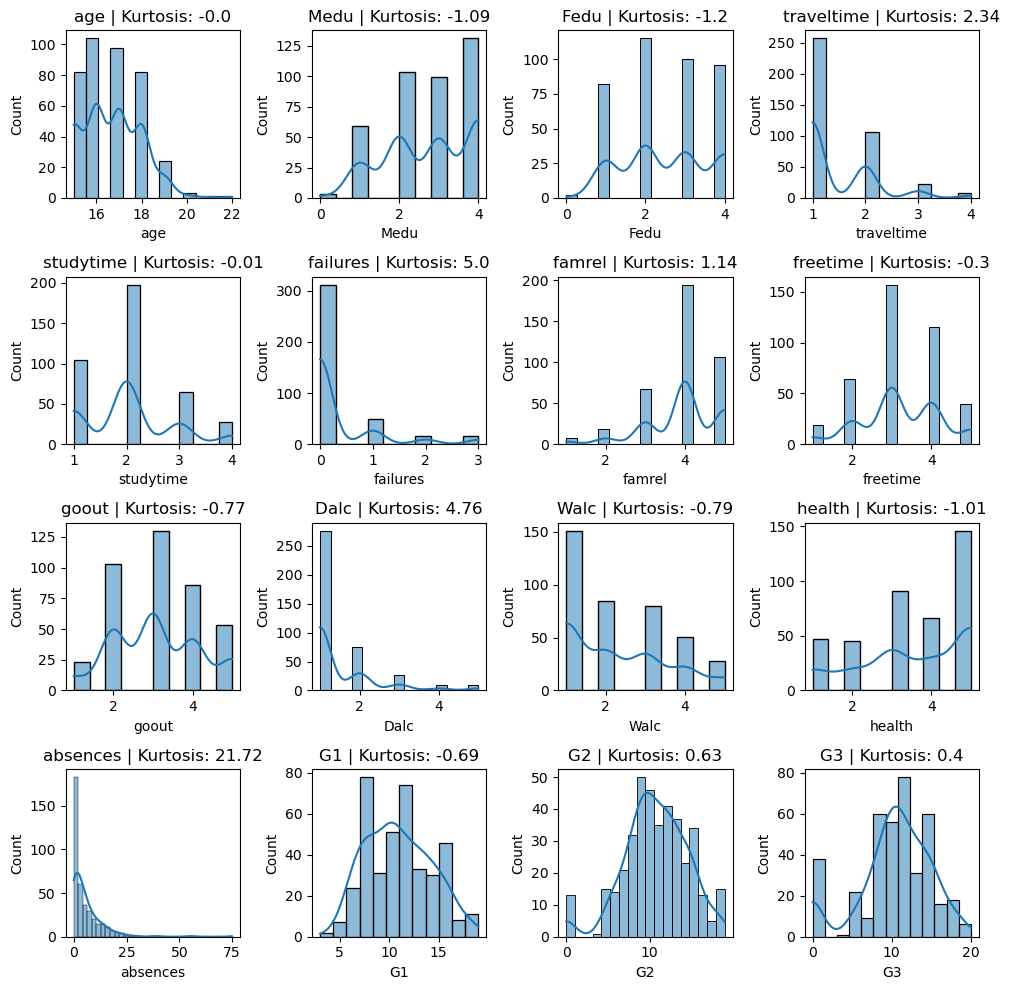

In [6]:
import seaborn as sns

numerical = df.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(nrows= 4, ncols= 4, figsize=(10, 10))
axes = axes.flatten()

for i , col in enumerate(numerical):
    kurt = df[col].kurt().round(2)
    sns.histplot(df[col], ax=axes[i], kde=True)
    axes[i].set_title(f"{col} | Kurtosis: {kurt}")

plt.tight_layout()
plt.show()

**Most Outliers are most likely to be in absences**

# 3. Outliers Detection and Handling

In [7]:
numerical = df.select_dtypes(include='number').columns
Q1 = df[numerical].quantile(0.25)
Q3 = df[numerical].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[numerical] < Q1 - 1.5 * IQR) | (df[numerical] > Q3 + 1.5 * IQR))
outliers.sum()

age            1
Medu           0
Fedu           2
traveltime     8
studytime     27
failures      83
famrel        26
freetime      19
goout          0
Dalc          18
Walc           0
health         0
absences      15
G1             0
G2            13
G3             0
dtype: int64

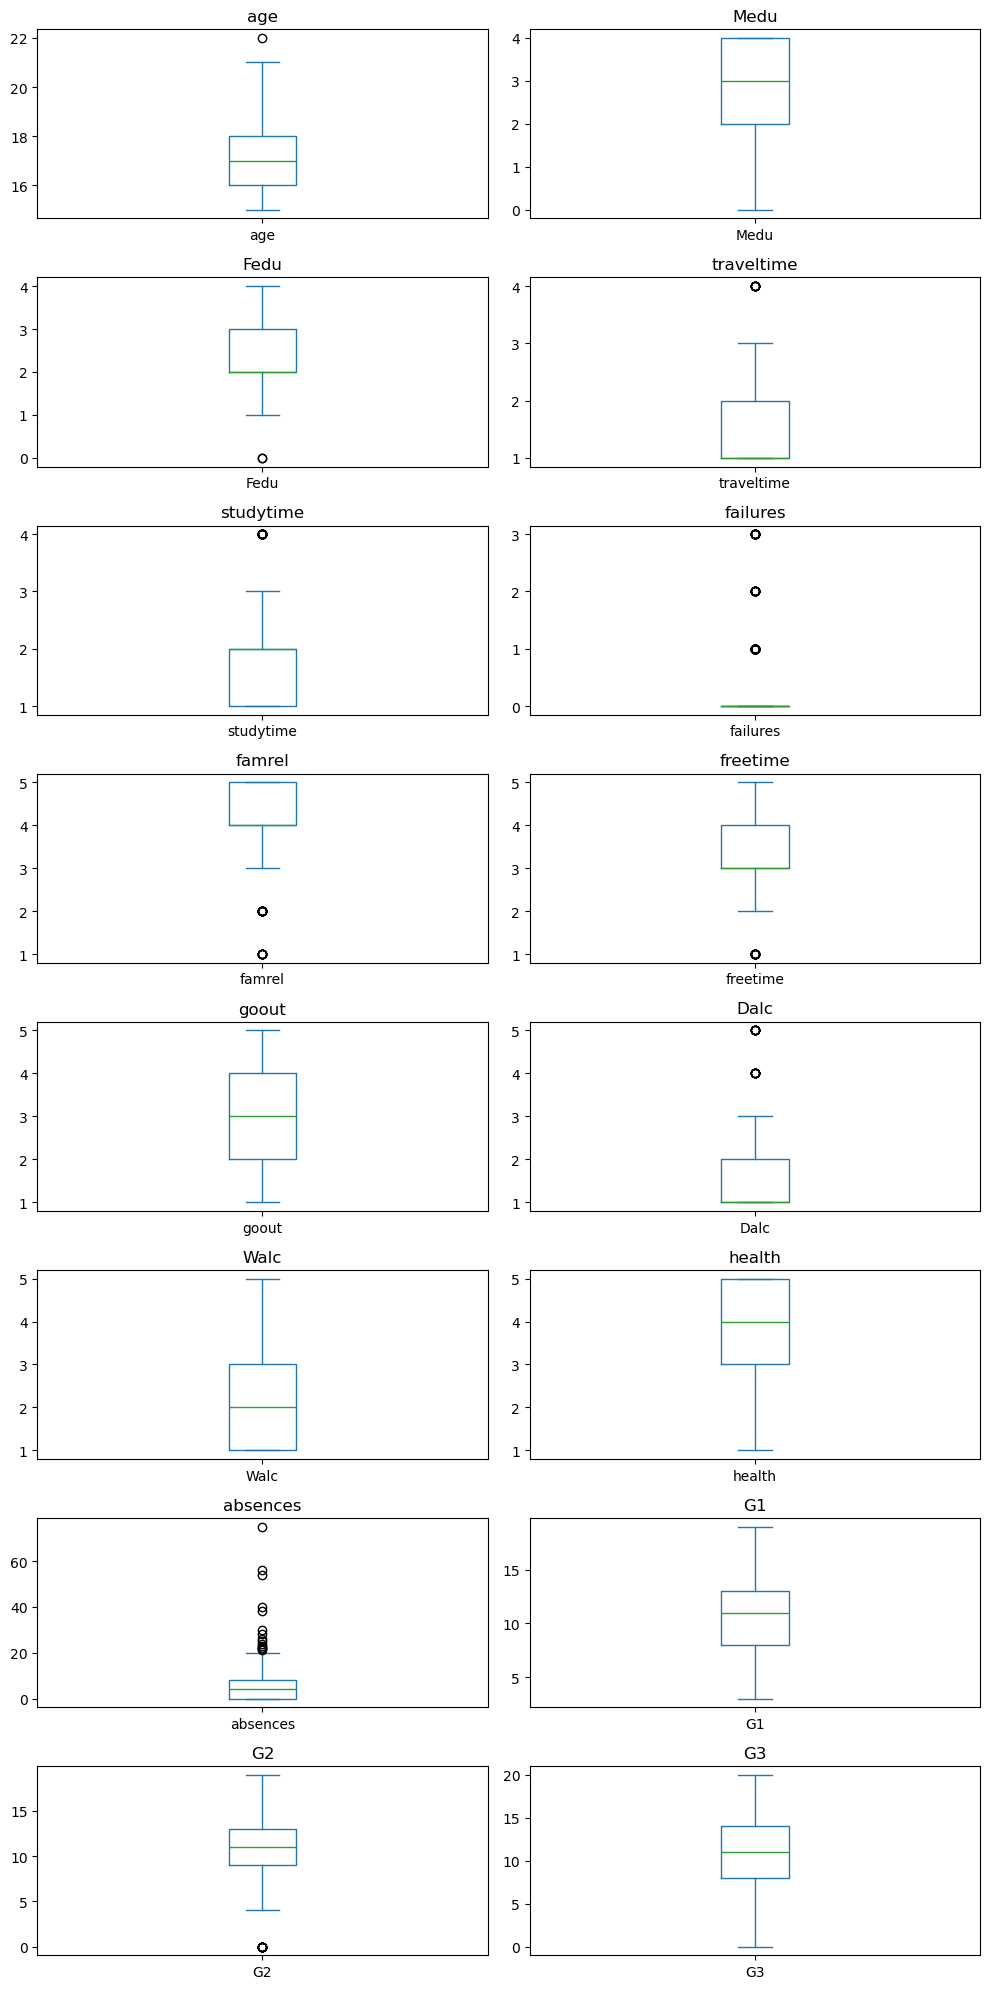

In [8]:
numerical = df.select_dtypes(include='number').columns.tolist()
fig, axes = plt.subplots(nrows= 8, ncols= 2, figsize=(10, 20))
axes = axes.flatten()

for i , col in enumerate(numerical):
    df[col].plot(kind= 'box', ax= axes[i], title= col)

plt.tight_layout()
plt.show()

In [9]:
outliers = [
            'age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 
            'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 
            'absences', 'G1', 'G2', 'G3'
           ]

for col in outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower= lower, upper= upper)

**Check NOW**

In [10]:
for col in outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {n}")

age: 0
Medu: 0
Fedu: 0
traveltime: 0
studytime: 0
failures: 0
famrel: 0
freetime: 0
goout: 0
Dalc: 0
Walc: 0
health: 0
absences: 0
G1: 0
G2: 0
G3: 0


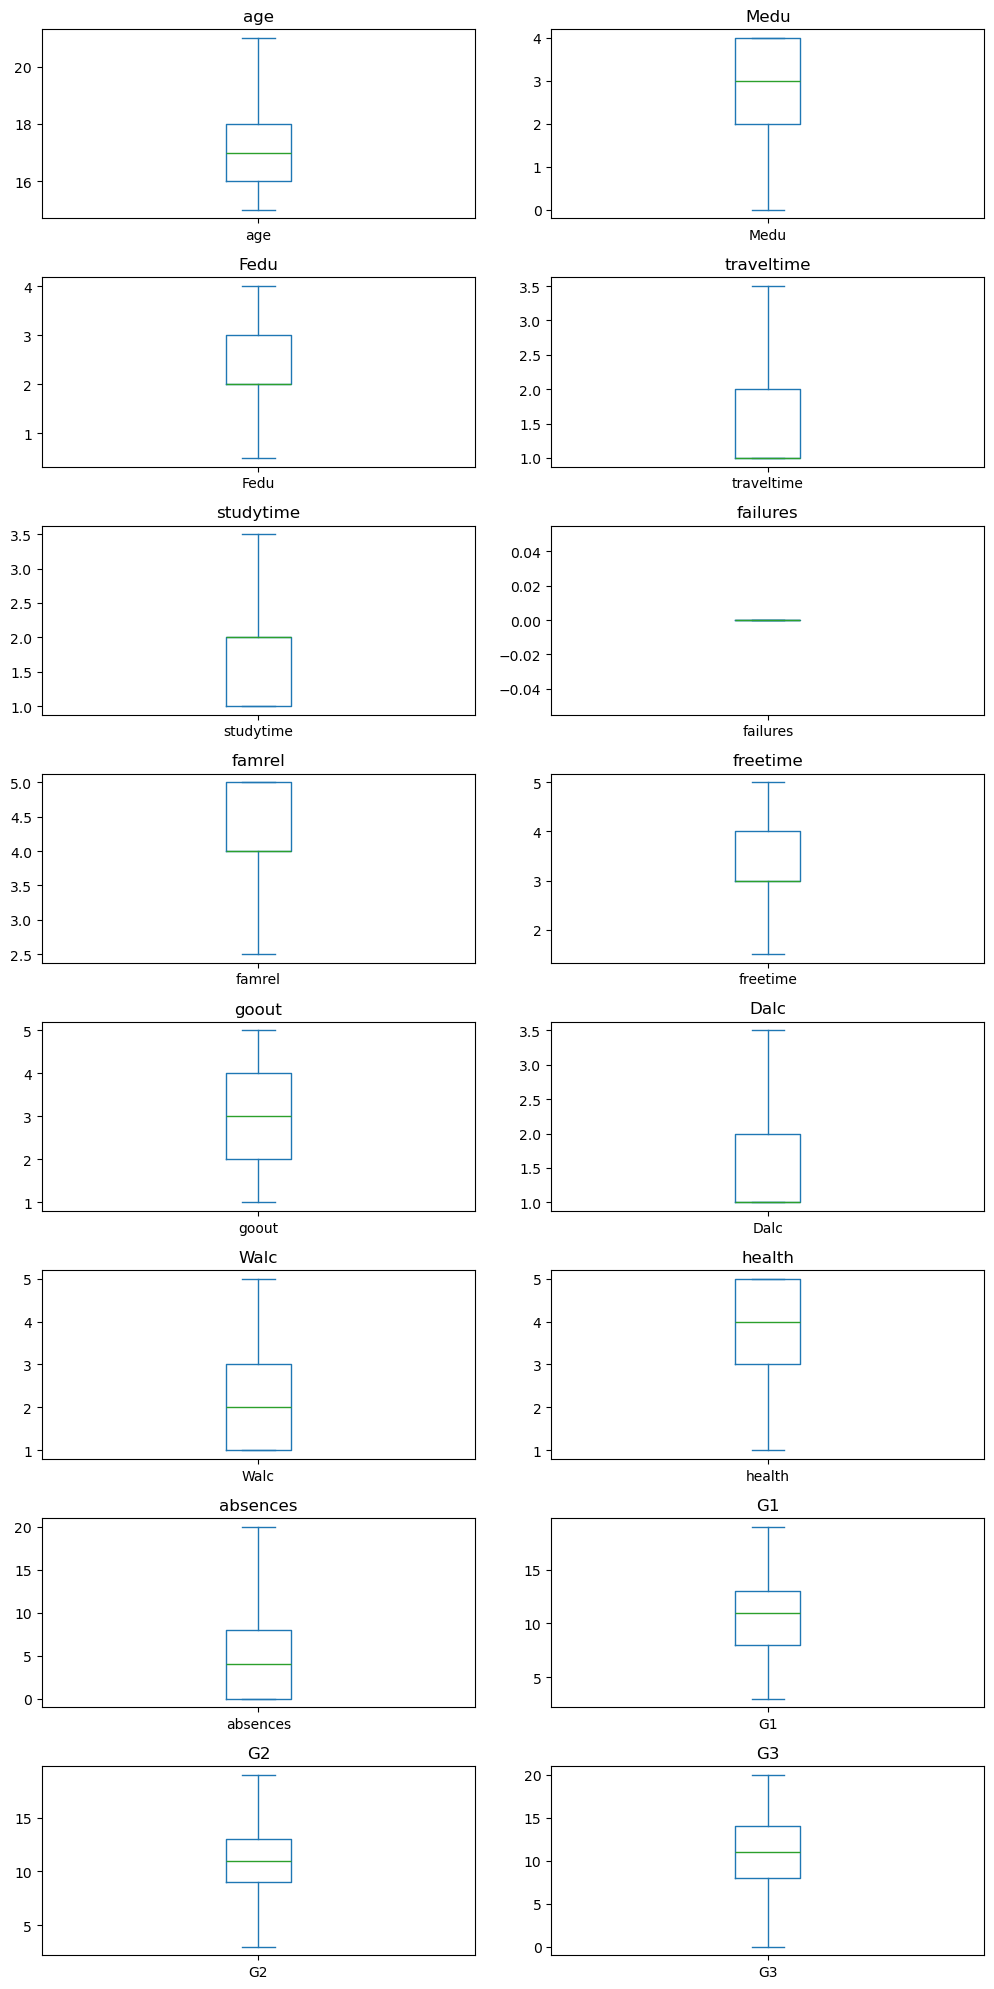

In [11]:
numerical = df.select_dtypes(include='number').columns.tolist()
fig, axes = plt.subplots(nrows= 8, ncols= 2, figsize=(10, 20))
axes = axes.flatten()

for i , col in enumerate(numerical):
    df[col].plot(kind= 'box', ax= axes[i], title= col)

plt.tight_layout()
plt.show()

**No More Outliers!!**

# 4. Correlation Analysis

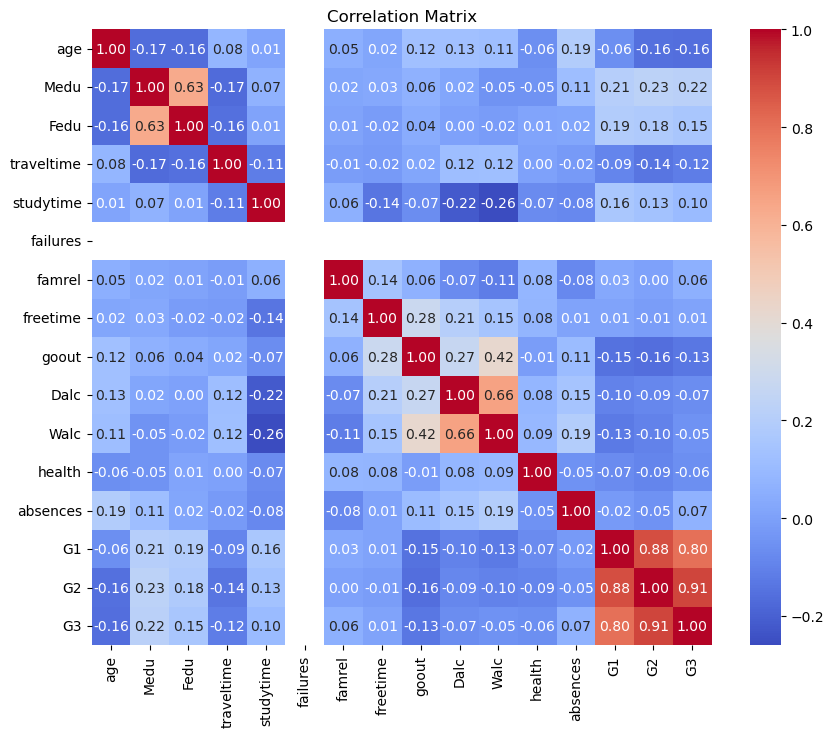

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**G1 and G2 show strong correlation with G3. Therefore we can conlude that students who perform well in earlier exams are more likely to get high grades in the final exam. This indicates that early academic performance is a strong predictor of the final outcome**

# 5. Classes Analysis

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   school      395 non-null    object 
 1   sex         395 non-null    object 
 2   age         395 non-null    int64  
 3   address     395 non-null    object 
 4   famsize     395 non-null    object 
 5   Pstatus     395 non-null    object 
 6   Medu        395 non-null    int64  
 7   Fedu        395 non-null    float64
 8   Mjob        395 non-null    object 
 9   Fjob        395 non-null    object 
 10  reason      395 non-null    object 
 11  guardian    395 non-null    object 
 12  traveltime  395 non-null    float64
 13  studytime   395 non-null    float64
 14  failures    395 non-null    int64  
 15  schoolsup   395 non-null    object 
 16  famsup      395 non-null    object 
 17  paid        395 non-null    object 
 18  activities  395 non-null    object 
 19  nursery     395 non-null    o

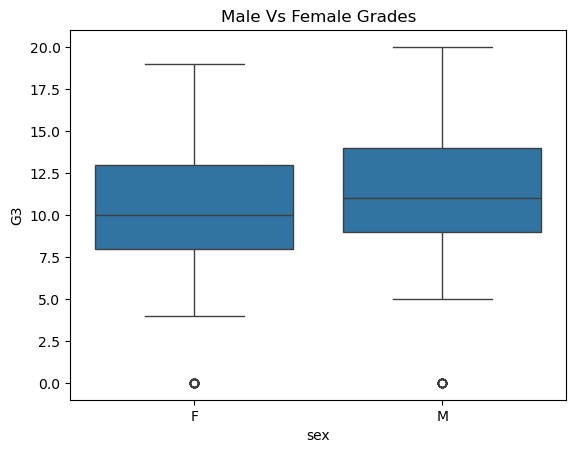

In [14]:
sns.boxplot(x= 'sex', y= 'G3', data= df)
plt.title('Male Vs Female Grades')
plt.show()

**Male students tend to perform slightly better on average in G3 grades compared to female students, though the difference is not dramatic and both groups show similar variability in performance.**

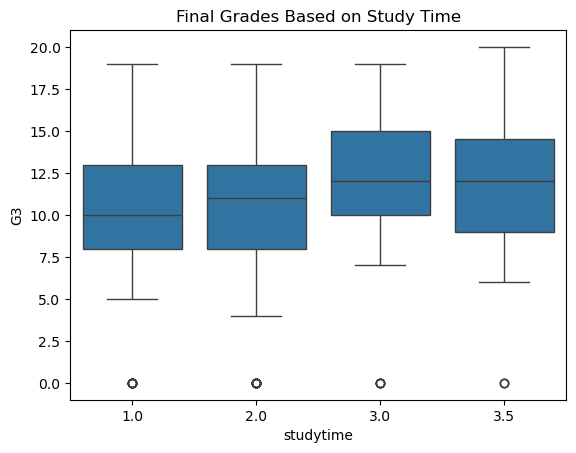

In [15]:
sns.boxplot(x= 'studytime', y= 'G3', data= df)
plt.title('Final Grades Based on Study Time')
plt.show()

**Students with more studytime got higher grades**

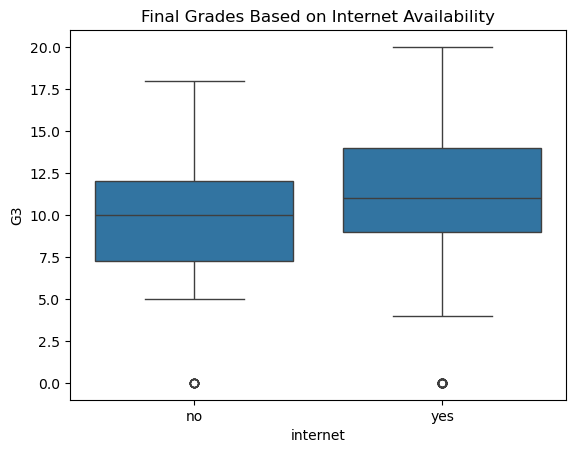

In [16]:
sns.boxplot(x= 'internet', y= 'G3', data= df)
plt.title('Final Grades Based on Internet Availability')
plt.show()


**Students who have internet access tend to achieve slightly higher final grades on average.This may suggest that access to online resources can support better learning.**


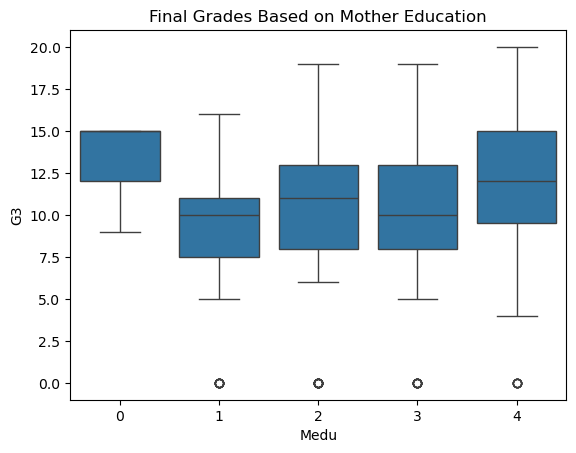

In [17]:
sns.boxplot(x= 'Medu', y= 'G3', data= df)
plt.title('Final Grades Based on Mother Education')
plt.show()

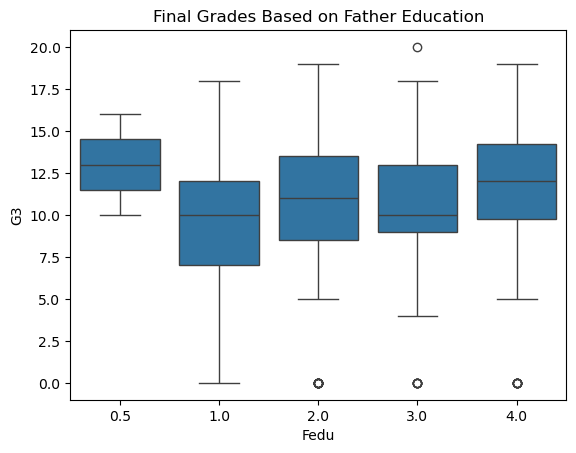

In [18]:
sns.boxplot(x= 'Fedu', y= 'G3', data= df)
plt.title('Final Grades Based on Father Education')
plt.show()

**Students with higher Mother education tend to achieve better grades on average in comparison with Father education which shows less relationship with the students grades. This shows that parental education plays a role in academic support especially marental education**

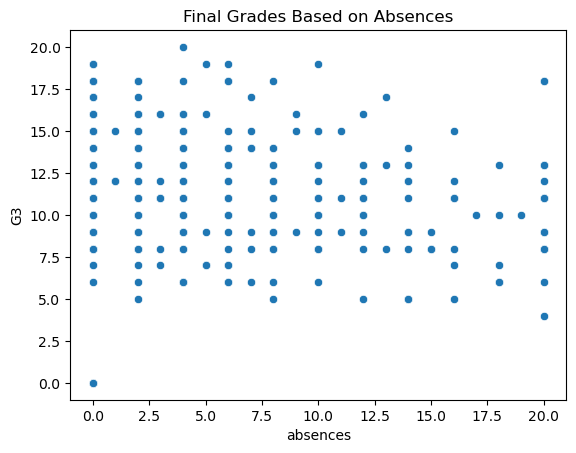

In [19]:
sns.scatterplot(x= 'absences', y= 'G3', data= df)
plt.title('Final Grades Based on Absences')
plt.show()

**While absences show a slight negative trend with final grades, the correlation is too weak and scattered to be a reliable predictor. Students across all absence levels achieved similar grade ranges, indicating attendance alone does not determine academic success.**

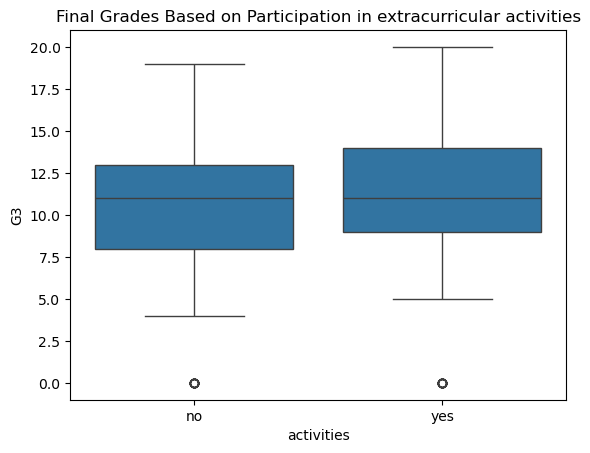

In [20]:
sns.boxplot(x= 'activities', y= 'G3', data= df)
plt.title('Final Grades Based on Participation in extracurricular activities')
plt.show()

**Participation in extracurricular activities has no significant effect on final grades, as both groups show nearly identical median scores and distributions. This suggests that engaging in extra activities neither helps nor hinders academic performance in this dataset.**

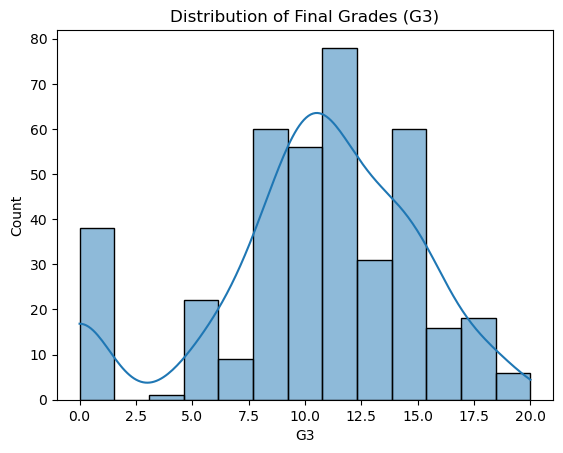

In [21]:
sns.histplot(df['G3'], kde=True)
plt.title('Distribution of Final Grades (G3)')
plt.show()

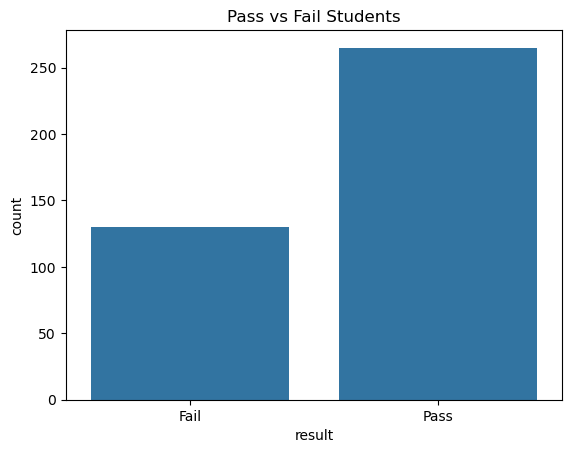

In [22]:
df['result'] = df['G3'].apply(lambda x: 'Pass' if x >= 10 else 'Fail')
sns.countplot(x='result', data=df)
plt.title('Pass vs Fail Students')
plt.show()

# 6. Preprocessing

In [23]:
# Splitting
from sklearn.model_selection import train_test_split

X = df.drop('G3', axis= 1)
y = df['G3']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size= 0.25, random_state= 42)

print(f"Train Size:            {X_train.shape}")
print(f"Validation Size:       {X_val.shape}")
print(f"Test Size:             {X_test.shape}")

Train Size:            (237, 33)
Validation Size:       (79, 33)
Test Size:             (79, 33)


In [24]:
# Scaling

from sklearn.preprocessing import StandardScaler
numerics = X.select_dtypes(include=np.number).columns
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train[numerics])
X_val_scaled = scaler.transform(X_val[numerics])
X_test_scaled = scaler.transform(X_test[numerics])

print(f"Train mean: {X_train_scaled.mean().round(1)}")
print(f"Train std:  {X_train_scaled.std().round(1)}")

Train mean: 0.0
Train std:  1.0


In [25]:
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_val_scaled shape:   {X_val_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")
print(f"y_train shape:        {y_train.shape}")
print(f"y_val shape:          {y_val.shape}")
print(f"y_test shape:         {y_test.shape}")


X_train_scaled shape: (237, 15)
X_val_scaled shape:   (79, 15)
X_test_scaled shape:  (79, 15)
y_train shape:        (237,)
y_val shape:          (79,)
y_test shape:         (79,)


In [26]:
x_train_scaled_df = pd.DataFrame(X_train_scaled, columns= numerics)

x_train_scaled_df.describe().round(2)

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2
count,237.00,237.00,237.00,237.00,237.00,237.0,237.00,237.00,237.00,237.00,237.00,237.00,237.00,237.00,237.00
mean,0.00,0.00,0.00,-0.00,0.00,0.0,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,0.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.48,-2.57,-1.91,-0.66,-1.37,0.0,-1.92,-1.82,-1.90,-0.57,-1.01,-1.78,-0.92,-1.84,-2.22
25%,-0.65,-0.68,-0.51,-0.66,-0.03,0.0,-0.01,-0.26,-1.02,-0.57,-1.01,-0.32,-0.92,-0.94,-0.53
50%,0.19,0.26,0.43,-0.66,-0.03,0.0,-0.01,-0.26,-0.14,-0.57,-0.23,-0.32,-0.25,-0.03,0.04
75%,1.02,1.20,0.43,0.81,-0.03,0.0,1.27,0.77,0.74,0.79,0.56,1.13,0.42,0.57,0.60
max,2.69,1.20,1.36,3.01,1.97,0.0,1.27,1.81,1.62,2.84,2.14,1.13,2.42,2.38,2.01


In [27]:
# Save splits as csv files
pd.DataFrame(X_train_scaled, columns=numerics).assign(Outcome=y_train.values).to_csv('train.csv', index=False)
pd.DataFrame(X_val_scaled,   columns=numerics).assign(Outcome=y_val.values).to_csv('val.csv',   index=False)
pd.DataFrame(X_test_scaled,  columns=numerics).assign(Outcome=y_test.values).to_csv('test.csv',  index=False)

print("Saved: train.csv, val.csv, test.csv with G3 as target")

Saved: train.csv, val.csv, test.csv with G3 as target
